<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/Aexp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<center>Experiment - 4**

**AIM:**

To build and train a Convolutional Neural Network (CNN) for classifying color images from the CIFAR-10 dataset into 10
distinct classes.

**PRE-REQUISITES:**

1. Basics of Machine Learning
2. Python Programming
3. Knowledge on Numpy, Pandas, Matplotlib, TensorFlow/ Keras
4. Jupyter Notebook
5. Data Pre-Processing Techniques
6. Knowledge on Neural Networks

**CIFAR-10 Dataset**



*   CIFAR-10 contains 60,000 color images of size 32x32 pixels, split into 10 classes


*   The classes include common objects like airplane, car, bird, cat, deer, dog, frog, horse, ship and truck.



*   It has 50,000 training images and 10,000 test images, divided among the 10 classes.






**1. Importing the Basic Libraries**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# It tells Jupyter to display Matplotlib plots directly below the code cell that produced them, inside
# You don’t need to call plt.show()
%matplotlib inline

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
# Load the CIFAR-10 dataset as Training and Testing data
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [ ]:
X_train.shape, y_train.shape
# 50,000 Images, each image is 32x32 pixel

((50000, 32, 32, 3), (50000, 1))

array([[[159, 102, 101],
        [150,  91,  95],
        [153,  95,  97],
        ...,
        [ 91,  71,  56],
        [ 74,  63,  55],
        [ 76,  58,  55]],

       [[142,  75,  68],
        [146,  72,  66],
        [155,  76,  65],
        ...,
        [127, 105,  71],
        [122, 111,  93],
        [ 86,  69,  61]],

       [[109,  67,  75],
        [ 99,  58,  60],
        [105,  59,  52],
        ...,
        [137, 112,  80],
        [163, 132, 105],
        [ 93,  72,  71]],

       ...,

       [[244, 129,  70],
        [240, 123,  65],
        [241, 122,  65],
        ...,
        [156,  42,  15],
        [179,  59,  26],
        [200,  73,  36]],

       [[246, 133,  74],
        [243, 128,  72],
        [243, 127,  70],
        ...,
        [162,  44,  14],
        [178,  56,  22],
        [192,  65,  27]],

       [[246, 139,  82],
        [243, 133,  78],
        [244, 132,  77],
        ...,
        [166,  47,  14],
        [173,  51,  17],
        [182,  57,  19]]], dtype=uint8)
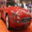

In [ ]:
# Reading one Image of the CIFAR-10 X_train data
X_train[5]

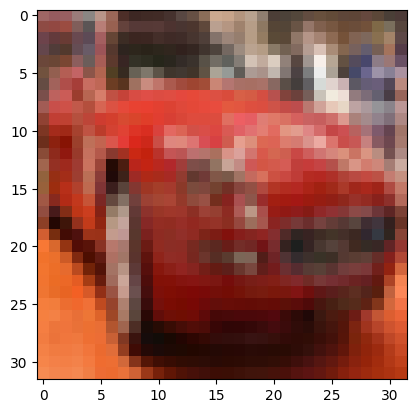

In [ ]:
plt.imshow(X_train[5])

In [ ]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

**3. Pre-Process the Data as required**

 Since, this is classification problem, we need to encode the y_train data    
  If not the model assume the y label is a continuous data

In [ ]:
# Import the library
from tensorflow.keras.utils import to_categorical

In [ ]:
# Shape of the y_train
y_train.shape

(50000, 1)

**One-hot Encoding the y**

In [ ]:
# Convert class labels to one-hot encoding
# num_classes=10 tells the function that your classification task has 10 different classes

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [ ]:
# the index of one represents the actual output digit
# the 2th row belongs to digit 1
y_train_cat[2]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

**Scaling the Data**

In [ ]:
# Each pixel value of every image is ranging from 0 to 255
# So, normalize every value in between 0 to 1
# Normalize the pixel values to range [0, 1]
# the max value of any pixel is 255, so dividing each value with 255 will normalize the value to maximum
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Shapes of the data
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

**4. Build the Model**

In [ ]:
# import the libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

**Create the Model**

In [ ]:
# Model Instance
model = Sequential()

In [ ]:
# For more complex data, better to add more number of convolution & pooling layers
# Convolution Layer
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(32,32,3),activation='relu'))
# Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))
# Convolution Layer
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(32,32,3),activation='relu'))
# Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
 #Flatten Layer
model.add(Flatten())

In [ ]:
# Dense Layers (Fully Connected Layers)
model.add(Dense(256,activation='relu'))

In [ ]:
# Output Layer (For multiclass use softmax)
model.add(Dense(10,activation='softmax'))

**Compile the Model**

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,610 (881.29 KB)

 Trainable params: 225,610 (881.29 KB)

 Non-trainable params: 0 (0.00 B)

**4. Train the Model**

In [ ]:
# Train the model with Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=1)

In [ ]:
# Train the model
model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test,y_test_cat), callbacks=[early_stop])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.3650 - loss: 1.7375 - val_accuracy: 0.5423 - val_loss: 1.2722
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5716 - loss: 1.2167 - val_accuracy: 0.5823 - val_loss: 1.1728
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6305 - loss: 1.0551 - val_accuracy: 0.6319 - val_loss: 1.0475
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.6677 - loss: 0.9497 - val_accuracy: 0.6465 - val_loss: 1.0137
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7023 - loss: 0.8576 - val_accuracy: 0.6536 - val_loss: 0.9994
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7250 - loss: 0.7891 - val_accuracy: 0.6642 - val_loss: 0.9726
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 39ms/step - accuracy: 0.7501 - loss: 0.7164 - val_accuracy: 0.6627 - val_loss: 0.9835


**5. Evaluate the Model**

In [ ]:
# Plot the accuracy because we used accuracy metric while compiling the model
metrics = pd.DataFrame(model.history.history)
metrics

,accuracy,loss,val_accuracy,val_loss
0,0.45408,1.512145,0.5423,1.272152
1,0.58224,1.186399,0.5823,1.172781
2,0.63578,1.044710,0.6319,1.047513
3,0.66938,0.947554,0.6465,1.013661
4,0.70042,0.864227,0.6536,0.999408
5,0.72060,0.797926,0.6642,0.972615
6,0.74530,0.731260,0.6627,0.983517


<Axes: >

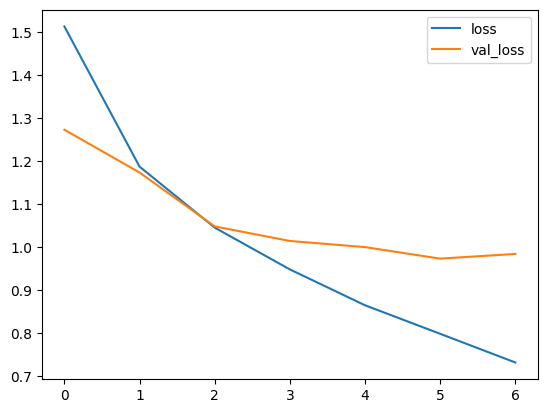

In [ ]:
# Plot loss
metrics[['loss', 'val_loss']].plot()

<Axes: >

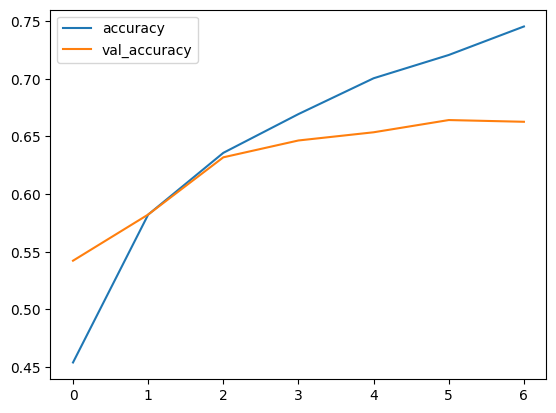

In [ ]:
# Plot accuracy
metrics[['accuracy', 'val_accuracy']].plot()

**Classification report**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Get the Classifications on test data
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
# y_test is one-hot encoded, convert it to class labels too
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
# Classification Report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.78      0.69      0.73      1000
           1       0.77      0.78      0.77      1000
           2       0.63      0.51      0.57      1000
           3       0.45      0.49      0.47      1000
           4       0.65      0.56      0.60      1000
           5       0.49      0.60      0.54      1000
           6       0.73      0.73      0.73      1000
           7       0.77      0.66      0.71      1000
           8       0.79      0.78      0.78      1000
           9       0.65      0.81      0.72      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test,y_pred))

[[690  35  59  23  22  20  12   6  82  51]
 [ 21 778   0   9   3   9  12   2  22 144]
 [ 56   7 514  80  84 114  65  29  27  24]
 [ 10  17  47 494  65 223  55  31  18  40]
 [ 18   9  70  90 564  78  70  62  15  24]
 [  6   6  45 195  39 602  26  49   7  25]
 [  5  18  30  92  32  47 734   9   9  24]
 [ 14  11  31  54  54 103  14 658   7  54]
 [ 52  39  12  27   4  14   8   4 780  60]
 [ 17  92   6  23   1   8   8   7  25 813]]


**Classiying the new image**

In [ ]:
from tensorflow.keras.preprocessing import image
from PIL import Image
# RGB Image
new_image = Image.open('/content/car-cars-lamborghini-aventador-63764.jpg').convert('RGB')

In [ ]:
# Resize to 28x28
new_image = new_image.resize((32, 32))

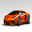

In [ ]:
new_image

In [ ]:
# Convert to NumPy array and normalize
img_array = np.array(new_image)
img_array = img_array / 255.0

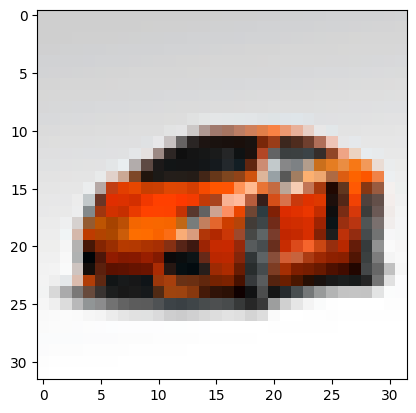

In [ ]:
plt.imshow(img_array)

In [ ]:
# Reshape to match input shape of model: (1, 32, 32, 3)
img_array = img_array.reshape(1, 32, 32, 3)

In [ ]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [ ]:
np.argmax(pred, axis=1)
# Index 7 belongs to horse

array([1])

RESULT:

A Convolutional Neural Network (CNN) was successfully implemented to classify the CIFAR-10 dataset. The model
demonstrated average performance in recognizing various object classes in color images, achieving an accuracy of 67% .